citesc CSV-urile originale 

In [1]:
import pandas as pd

fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

print("Fake: ", fake.shape)
print("True: ", true.shape)

fake.head()

Fake:  (23481, 4)
True:  (21417, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


pun label-uri 
fake -> 0
true -> 1

In [2]:
fake["label"] = 0
true["label"] = 1 

df = pd.concat([fake, true], ignore_index=True)

print(df.shape)
print(df["label"].value_counts())
df.head()

(44898, 5)
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


creez coloana content

In [3]:
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")

df["content"] = df["title"] + " " + df["text"]

df[["content", "label"]].head()

,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,0
4,Pope Francis Just Called Out Donald Trump Dur...,0


curat textul

In [4]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_content"] = df["content"].apply(clean_text)

df[["content", "clean_content", "label"]].head()

,content,clean_content,label
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends out embarrassing new year s...,0
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian c...,0
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke becomes an internet joke ...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump is so obsessed he even has obama s name ...,0
4,Pope Francis Just Called Out Donald Trump Dur...,pope francis just called out donald trump duri...,0


fac subset mai mic -> ca sa nu imi ia atata de mult

In [5]:
fake_sample = df[df["label"] == 0].sample(3000, random_state=42)
true_sample = df[df["label"] == 1].sample(3000, random_state=42)

df_small = pd.concat([fake_sample, true_sample], ignore_index=True)
df_small = df_small.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_small.shape)
print(df_small["label"].value_counts())

(6000, 7)
label
0    3000
1    3000
Name: count, dtype: int64


salvez csv termporar (ca sa pot lucra eu pe partea mea pana face persoana 1)

In [6]:
df_small[["content", "clean_content", "label"]].to_csv(
    "../data/processed_news.csv",
    index=False
)

print("Temporary processed_news.csv created.")

Temporary processed_news.csv created.


verific daca e ok

In [7]:
test_df = pd.read_csv("../data/processed_news.csv")

print(test_df.shape)
print(test_df.head())

(6000, 3)
                                             content  \
0   WATCH: Trump Just Told All The Anti-Gay Bigot...   
1  China backs U.N. call for justice in Yemen, U....   
2  THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...   
3  WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...   
4  Lawmakers aim to delay U.S. ceding control of ...   

                                       clean_content  label  
0  watch trump just told all the anti gay bigots ...      0  
1  china backs u n call for justice in yemen u s ...      1  
2  the people s president trump meets with coal w...      0  
3  wsj reporter rips into dem candidates for thei...      0  
4  lawmakers aim to delay u s ceding control of i...      1  


TASK 1: citesc processed_news.csv

In [8]:
import pandas as pd

df = pd.read_csv("../data/processed_news.csv")

df.head()

,content,clean_content,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,watch trump just told all the anti gay bigots ...,0
1,"China backs U.N. call for justice in Yemen, U....",china backs u n call for justice in yemen u s ...,1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,the people s president trump meets with coal w...,0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,wsj reporter rips into dem candidates for thei...,0
4,Lawmakers aim to delay U.S. ceding control of ...,lawmakers aim to delay u s ceding control of i...,1


TASK 2: verific coloanele

In [9]:
print(df.columns)
print(df.isnull().sum())
print(df["label"].value_counts())

df = df.dropna(subset=["clean_content", "label"])
df["clean_content"] = df["clean_content"].astype(str)

Index(['content', 'clean_content', 'label'], dtype='str')
content          0
clean_content    1
label            0
dtype: int64
label
0    3000
1    3000
Name: count, dtype: int64


TASK 3: train si test split

In [10]:
from sklearn.model_selection import train_test_split

X = df["clean_content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

print("\nTrain distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Training set size: 4799
Testing set size: 1200

Train distribution:
label
1    2400
0    2399
Name: count, dtype: int64

Test distribution:
label
0    600
1    600
Name: count, dtype: int64


TASK 4: creez subset pentru rulare mai rapida -> asta e pt DistilBERT

TASK 5: instalare si import de transformers is torch

In [11]:
X_train_small = X_train.iloc[:1000]
y_train_small = y_train.iloc[:1000]

X_test_small = X_test.iloc[:300]
y_test_small = y_test.iloc[:300]

print("Small train size:", X_train_small.shape[0])
print("Small test size:", X_test_small.shape[0])

print("\nSmall train distribution:")
print(y_train_small.value_counts())

print("\nSmall test distribution:")
print(y_test_small.value_counts())

Small train size: 1000
Small test size: 300

Small train distribution:
label
1    512
0    488
Name: count, dtype: int64

Small test distribution:
label
0    150
1    150
Name: count, dtype: int64


AGENT 2: DistilBERT agent pentru feature extraction 

TASK 6: incarcare tokenizer DistilBERT

In [12]:
import torch
import transformers
import tqdm

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("tqdm imported successfully")

torch: 2.12.0+cpu
transformers: 5.8.1
tqdm imported successfully


In [13]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)

bert_model.eval()

print("Using device:", device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cpu


TASK 7: functia de feature extraction

In [14]:
def extract_bert_features(texts, batch_size=8, max_length=512):
    features = []

    texts = list(texts)

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[i:i + batch_size]

            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            encoded = {
                key: value.to(device)
                for key, value in encoded.items()
            }

            outputs = bert_model(**encoded)

            batch_features = outputs.last_hidden_state[:, 0, :]

            features.append(batch_features.cpu().numpy())

    return np.vstack(features)

TASK 8: generez feature-uri BERT pentru train si test

incerc prima data cu un subset mic

In [15]:
X_train_small = X_train.iloc[:300]
y_train_small = y_train.iloc[:300]

X_test_small = X_test.iloc[:100]
y_test_small = y_test.iloc[:100]

In [16]:
X_train_bert = extract_bert_features(X_train_small, batch_size=8)
X_test_bert = extract_bert_features(X_test_small, batch_size=8)

print("Train BERT features shape:", X_train_bert.shape)
print("Test BERT features shape:", X_test_bert.shape)

  0%|          | 0/38 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

Train BERT features shape: (300, 768)
Test BERT features shape: (100, 768)


AGENT 3 -> CLASSIFIER + EVALUARE 
 - folosesc Logistic Regression

TASK 9:  antrenez Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(max_iter=1000)

classifier.fit(X_train_bert, y_train_small)

y_pred = classifier.predict(X_test_bert)

TASK 10: evaluare model (calculez accuracy + classification repor + confusion matrix)

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test_small, y_pred)

print("Accuracy:", accuracy)

print("\nClassification report:")
print(classification_report(
    y_test_small,
    y_pred,
    target_names=["FAKE", "REAL"]
))

print("\nConfusion matrix:")
print(confusion_matrix(y_test_small, y_pred))

Accuracy: 0.93

Classification report:
              precision    recall  f1-score   support

        FAKE       0.96      0.90      0.93        52
        REAL       0.90      0.96      0.93        48

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100


Confusion matrix:
[[47  5]
 [ 2 46]]


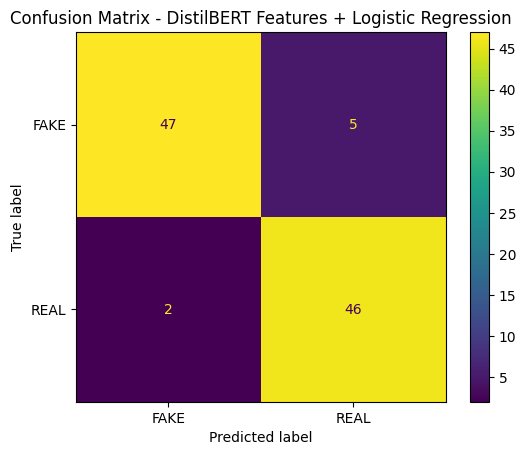

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_small,
    y_pred,
    display_labels=["FAKE", "REAL"]
)

plt.title("Confusion Matrix - DistilBERT Features + Logistic Regression")
plt.show()

TASK 11: salvez feature-urile BERT

In [22]:
from pathlib import Path
import numpy as np

Path("../data/bert_features").mkdir(parents=True, exist_ok=True)

np.save("../data/bert_features/X_train_bert.npy", X_train_bert)
np.save("../data/bert_features/X_test_bert.npy", X_test_bert)
np.save("../data/bert_features/y_train_small.npy", y_train_small.to_numpy())
np.save("../data/bert_features/y_test_small.npy", y_test_small.to_numpy())

print("DistilBERT features saved successfully.")

DistilBERT features saved successfully.


TASK 12: functia finala de predictie

In [23]:
def predict_news(text):
    cleaned_text = clean_text(text)

    bert_features = extract_bert_features([cleaned_text], batch_size=1)

    prediction = classifier.predict(bert_features)[0]

    if prediction == 1:
        return "REAL"
    else:
        return "FAKE"

TASK 13: testez pe exeple noi

In [24]:
examples = [
    "Government officials announced a new education reform after a parliamentary vote.",
    "Breaking news: aliens have landed in New York and started giving interviews.",
    "The central bank reported a change in interest rates after the latest meeting.",
    "A secret miracle pill can cure all diseases overnight, doctors are shocked."
]

for text in examples:
    print(text)
    print("Prediction:", predict_news(text))
    print()

Government officials announced a new education reform after a parliamentary vote.


  0%|          | 0/1 [00:00<?, ?it/s]

Prediction: REAL

Breaking news: aliens have landed in New York and started giving interviews.


  0%|          | 0/1 [00:00<?, ?it/s]

Prediction: FAKE

The central bank reported a change in interest rates after the latest meeting.


  0%|          | 0/1 [00:00<?, ?it/s]

Prediction: REAL

A secret miracle pill can cure all diseases overnight, doctors are shocked.


  0%|          | 0/1 [00:00<?, ?it/s]

Prediction: FAKE

